## FASE 1 — Carregamento e Análise Exploratória (EDA)

In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, ImageOps
import os

from sklearn.datasets import fetch_openml

print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


## Fase 2- Baixar e Carregar o dataset MINIST

In [66]:
print("Baixando o dataset MNIST...")

mnist = fetch_openml(
    'mnist_784',
    version=1,
    as_frame=False,
    parser='auto'
)

X = mnist.data
y = mnist.target

print("Download finalizado com sucesso!")

Baixando o dataset MNIST...
Download finalizado com sucesso!


## Resumo do código assima:

             DATASET MNIST
                   │
                   ▼
          ┌─────────────────┐
          │ Imagens         │
          │ de números      │
          │ escritos à mão  │
          └─────────────────┘
                   │
          ┌────────┴────────┐
          ▼                 ▼
       X (dados)         y (rótulos)
          │                 │
          ▼                 ▼
     Pixels das         Número correto
      imagens             da imagem

## Verificar as dimensões dos dados

In [67]:
print("Dimensão de X:", X.shape)
print("Dimensão de y:", y.shape)

Dimensão de X: (70000, 784)
Dimensão de y: (70000,)


70000 → quantidade total de imagens.
784 → quantidade de pixels que representam cada imagem.
Cada imagem original possui 28 × 28 pixels.
28 × 28 = 784.
y possui um rótulo para cada imagem.

## Verificar a distribuição dos dígitos

In [68]:
valores, quantidades = np.unique(y, return_counts=True)

distribuicao = pd.DataFrame({
    "Dígito": valores,
    "Quantidade": quantidades
})

distribuicao

,Dígito,Quantidade
0,0,6903
1,1,7877
2,2,6990
3,3,7141
4,4,6824
5,5,6313
6,6,6876
7,7,7293
8,8,6825
9,9,6958


## Gráfico de distribuição dos dígitos

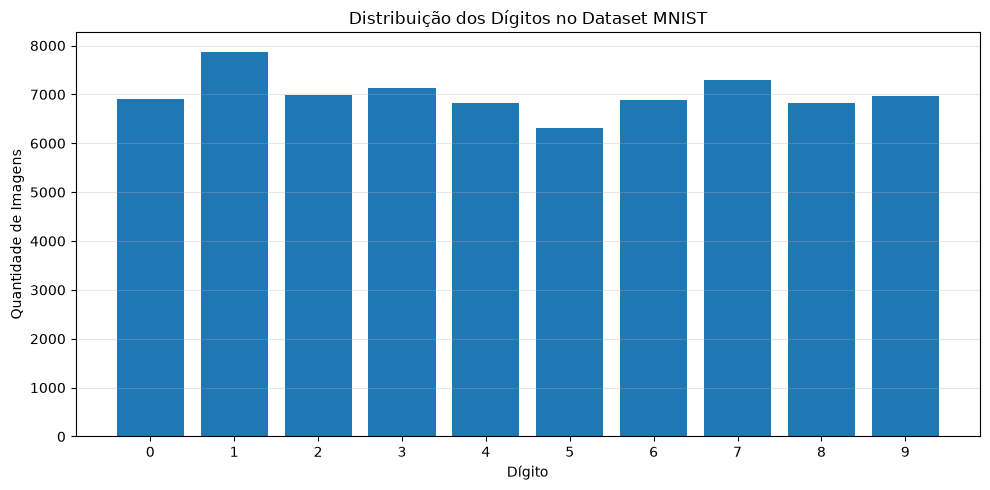

In [73]:
plt.figure(figsize=(10, 5))

plt.bar(distribuicao["Dígito"], distribuicao["Quantidade"])

plt.title("Distribuição dos Dígitos no Dataset MNIST")

plt.xlabel("Dígito")

plt.ylabel("Quantidade de Imagens")

plt.xticks(range(10))

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.savefig(
    "graficos/distribuicao_digitos.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Grade visual 2 × 5

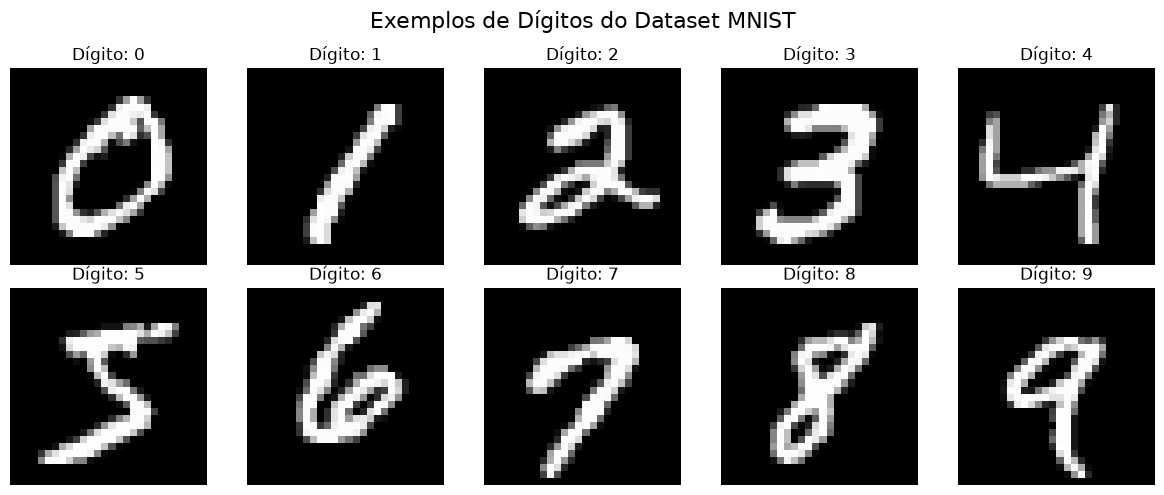

In [72]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for digito in range(10):

    indice = np.where(y == str(digito))[0][0]

    imagem = X[indice].reshape(28, 28)

    ax = axes.flat[digito]

    ax.imshow(imagem, cmap="gray")
    ax.set_title(f"Dígito: {y[indice]}")
    ax.axis("off")

plt.suptitle("Exemplos de Dígitos do Dataset MNIST", fontsize=16)

plt.tight_layout()

plt.savefig(
    "graficos/exemplos_digitos_mnist.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

O que esse código está fazendo?

range(10) → percorre os dígitos de 0 até 9;
np.where() → procura uma imagem daquele dígito;
reshape(28, 28) → transforma os 784 pixels novamente em uma imagem 28 × 28;
plt.subplots(2, 5) → cria a grade com 2 linhas e 5 colunas;
imshow() → mostra cada imagem.

## Interpretação da Estrutura dos Dados

O dataset MNIST é composto por imagens de dígitos manuscritos em escala de cinza, com dimensão de 28 × 28 pixels.

Cada pixel possui um valor de intensidade que varia de 0 a 255. Valores próximos de 0 representam regiões mais escuras, enquanto valores próximos de 255 representam regiões mais claras.

Embora cada imagem seja originalmente bidimensional, com 28 linhas e 28 colunas, os algoritmos de Machine Learning recebem os dados em formato vetorial. Por isso, cada imagem é representada por 784 features, pois:

28 × 28 = 784

Assim, cada linha da matriz X representa uma imagem, e cada coluna representa a intensidade de um pixel. A matriz X possui 70.000 imagens, cada uma representada por 784 valores, enquanto o vetor y contém o rótulo correspondente a cada imagem, indicando qual dígito, de 0 a 9, está representado.

##  Pré-processamento e Divisão dos Dados.

In [7]:
y = y.astype(int)

print("Tipo de y:", y.dtype)
print("Primeiros 10 rótulos:", y[:10])

Tipo de y: int64
Primeiros 10 rótulos: [5 0 4 1 9 2 1 3 1 4]


## Importar a função de divisão

In [8]:
from sklearn.model_selection import train_test_split

## Separar os dados de teste

In [9]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Treino + Validação:", X_temp.shape)
print("Teste:", X_test.shape)

Treino + Validação: (56000, 784)
Teste: (14000, 784)


## Separar Treino e Validação

In [10]:
X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.125,
    random_state=42,
    stratify=y_temp
)

print("Treino:", X_train.shape)
print("Validação:", X_val.shape)
print("Teste:", X_test.shape)

Treino: (49000, 784)
Validação: (7000, 784)
Teste: (14000, 784)


## Normalizar os dados

In [11]:
X_train_norm = X_train / 255.0
X_val_norm = X_val / 255.0
X_test_norm = X_test / 255.0

print("Normalização concluída!")
print("Menor valor no treino:", X_train_norm.min())
print("Maior valor no treino:", X_train_norm.max())

Normalização concluída!
Menor valor no treino: 0.0
Maior valor no treino: 1.0


## Justificativa da Normalização

Os valores originais dos pixels das imagens do MNIST variam de 0 a 255. Neste projeto, os dados foram normalizados para o intervalo de 0.0 a 1.0 por meio da divisão dos valores por 255.0.

A normalização é importante porque mantém todas as variáveis na mesma escala, evitando que valores numéricos maiores tenham influência desproporcional nos cálculos realizados pelos algoritmos.

Esse processo é especialmente importante para modelos baseados em distância, como o KNN, pois a comparação entre as imagens depende diretamente da distância entre seus valores de pixels. Também contribui para uma convergência mais estável e eficiente em modelos de redes neurais, facilitando o processo de otimização durante o treinamento.

Os conjuntos de treino, validação e teste foram normalizados utilizando a mesma regra, garantindo que os modelos recebam os dados em uma escala consistente.

## FASE 3 — Implementação e Treinamento dos 3 Modelos.

## MODELO 1: KNN
## Importar o KNN e as métricas

In [12]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

## Antes de treinar /Vamos  Testar diferentes valores de K

In [13]:
resultados_knn = []

for k in [3, 5, 7]:
    
    modelo_knn = KNeighborsClassifier(
        n_neighbors=k,
        weights="distance"
    )
    
    modelo_knn.fit(X_train_norm, y_train)
    
    y_val_pred = modelo_knn.predict(X_val_norm)
    
    acuracia = accuracy_score(y_val, y_val_pred)
    
    resultados_knn.append({
        "K": k,
        "Weights": "distance",
        "Acurácia Validação": acuracia
    })
    
    print(f"K = {k} | Acurácia: {acuracia:.4f}")

K = 3 | Acurácia: 0.9723
K = 5 | Acurácia: 0.9714
K = 7 | Acurácia: 0.9699


## Mostrar a tabela de resultados do KNN

In [14]:
df_resultados_knn = pd.DataFrame(resultados_knn)

df_resultados_knn

,K,Weights,Acurácia Validação
0,3,distance,0.972286
1,5,distance,0.971429
2,7,distance,0.969857


In [15]:
knn_final = KNeighborsClassifier(
    n_neighbors=3,
    weights="distance"
)

knn_final.fit(X_train_norm, y_train)

print("Modelo KNN treinado com sucesso!")

Modelo KNN treinado com sucesso!


## Avaliar o KNN na validação

In [16]:
y_val_pred_knn = knn_final.predict(X_val_norm)

acuracia_val_knn = accuracy_score(y_val, y_val_pred_knn)

print(f"Acurácia final do KNN na validação: {acuracia_val_knn:.4f}")

Acurácia final do KNN na validação: 0.9723


## MODELO 2: RANDOM FOREST /Importar o Random Forest

In [17]:
from sklearn.ensemble import RandomForestClassifier

In [18]:
resultados_rf = []

configuracoes_rf = [
    {"n_estimators": 50, "max_depth": 10},
    {"n_estimators": 100, "max_depth": 10},
    {"n_estimators": 100, "max_depth": 20}
]

for config in configuracoes_rf:
    
    modelo_rf = RandomForestClassifier(
        n_estimators=config["n_estimators"],
        max_depth=config["max_depth"],
        random_state=42,
        n_jobs=-1
    )
    
    modelo_rf.fit(X_train_norm, y_train)
    
    y_val_pred_rf = modelo_rf.predict(X_val_norm)
    
    acuracia = accuracy_score(y_val, y_val_pred_rf)
    
    resultados_rf.append({
        "n_estimators": config["n_estimators"],
        "max_depth": config["max_depth"],
        "Acurácia Validação": acuracia
    })
    
    print(
        f"Árvores = {config['n_estimators']} | "
        f"Profundidade = {config['max_depth']} | "
        f"Acurácia = {acuracia:.4f}"
    )

Árvores = 50 | Profundidade = 10 | Acurácia = 0.9446
Árvores = 100 | Profundidade = 10 | Acurácia = 0.9464
Árvores = 100 | Profundidade = 20 | Acurácia = 0.9651


## Justificativa
Aumentar de 50 para 100 árvores trouxe uma pequena melhora.
Permitir profundidade máxima de 20 melhorou mais significativamente a capacidade da Random Forest de identificar padrões complexos nas imagens.
Mesmo assim, até agora o KNN continua com melhor resultado na validação:
KNN           → 97,23%
Random Forest → 96,51%

In [19]:
df_resultados_rf = pd.DataFrame(resultados_rf)

df_resultados_rf

,n_estimators,max_depth,Acurácia Validação
0,50,10,0.944571
1,100,10,0.946429
2,100,20,0.965143


## Treinar o Random Forest final

In [20]:
rf_final = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

rf_final.fit(X_train_norm, y_train)

print("Modelo Random Forest treinado com sucesso!")

Modelo Random Forest treinado com sucesso!


## Avaliar a Random Forest na validação

In [21]:
y_val_pred_rf = rf_final.predict(X_val_norm)

acuracia_val_rf = accuracy_score(y_val, y_val_pred_rf)

print(f"Acurácia final da Random Forest na validação: {acuracia_val_rf:.4f}")

Acurácia final da Random Forest na validação: 0.9651


## MODELO 3: MLP (Rede Neural) /Importar a MLP/Testar configurações da Rede Neural

In [22]:
from sklearn.neural_network import MLPClassifier

In [23]:
resultados_mlp = []

configuracoes_mlp = [
    {
        "hidden_layer_sizes": (100,),
        "learning_rate_init": 0.001
    },
    {
        "hidden_layer_sizes": (150,),
        "learning_rate_init": 0.001
    },
    {
        "hidden_layer_sizes": (150,),
        "learning_rate_init": 0.0005
    }
]

for config in configuracoes_mlp:

    modelo_mlp = MLPClassifier(
        hidden_layer_sizes=config["hidden_layer_sizes"],
        learning_rate_init=config["learning_rate_init"],
        max_iter=30,
        random_state=42,
        early_stopping=True,
        validation_fraction=0.1
    )

    modelo_mlp.fit(X_train_norm, y_train)

    y_val_pred_mlp = modelo_mlp.predict(X_val_norm)

    acuracia = accuracy_score(y_val, y_val_pred_mlp)

    resultados_mlp.append({
        "Camada Oculta": str(config["hidden_layer_sizes"]),
        "Learning Rate": config["learning_rate_init"],
        "Acurácia Validação": acuracia
    })

    print(
        f"Neurônios = {config['hidden_layer_sizes']} | "
        f"Learning Rate = {config['learning_rate_init']} | "
        f"Acurácia = {acuracia:.4f}"
    )

c:\Users\conta\Documents\MiniProjeto_MNIST\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (30) reached and the optimization hasn't converged yet.
  warnings.warn(


Neurônios = (100,) | Learning Rate = 0.001 | Acurácia = 0.9726


c:\Users\conta\Documents\MiniProjeto_MNIST\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (30) reached and the optimization hasn't converged yet.
  warnings.warn(


Neurônios = (150,) | Learning Rate = 0.001 | Acurácia = 0.9770
Neurônios = (150,) | Learning Rate = 0.0005 | Acurácia = 0.9719


c:\Users\conta\Documents\MiniProjeto_MNIST\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (30) reached and the optimization hasn't converged yet.
  warnings.warn(


## Tabela dos resultados da MLP

In [24]:
df_resultados_mlp = pd.DataFrame(resultados_mlp)

df_resultados_mlp

,Camada Oculta,Learning Rate,Acurácia Validação
0,"(100,)",0.0010,0.972571
1,"(150,)",0.0010,0.977000
2,"(150,)",0.0005,0.971857


## Treinar o modelo MLP final

In [25]:
mlp_final = MLPClassifier(
    hidden_layer_sizes=(150,),
    learning_rate_init=0.001,
    max_iter=30,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1
)

mlp_final.fit(X_train_norm, y_train)

print("Modelo MLP treinado com sucesso!")

Modelo MLP treinado com sucesso!


c:\Users\conta\Documents\MiniProjeto_MNIST\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (30) reached and the optimization hasn't converged yet.
  warnings.warn(


## Avaliar a MLP na validação

In [46]:
y_val_pred_mlp = mlp_final.predict(X_val_norm)

acuracia_val_mlp = accuracy_score(y_val, y_val_pred_mlp)

print(f"Acurácia final da MLP na validação: {acuracia_val_mlp:.4f}")

Acurácia final da MLP na validação: 0.9770


## Avaliação Comparativa de Desempenho/ Importar as métricas de avaliação

In [26]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

## previsões no conjunto de teste

In [27]:
y_test_pred_knn = knn_final.predict(X_test_norm)

y_test_pred_rf = rf_final.predict(X_test_norm)

y_test_pred_mlp = mlp_final.predict(X_test_norm)

print("Previsões dos três modelos concluídas!")

Previsões dos três modelos concluídas!


## Tabela com Accuracy, Precision, Recall e F1-Score

In [28]:
resultados_finais = []

modelos_resultados = {
    "KNN": y_test_pred_knn,
    "Random Forest": y_test_pred_rf,
    "MLP": y_test_pred_mlp
}

for nome_modelo, previsoes in modelos_resultados.items():

    resultados_finais.append({
        "Modelo": nome_modelo,
        "Accuracy": accuracy_score(y_test, previsoes),
        "Precision": precision_score(
            y_test,
            previsoes,
            average="weighted",
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            previsoes,
            average="weighted",
            zero_division=0
        ),
        "F1-Score": f1_score(
            y_test,
            previsoes,
            average="weighted",
            zero_division=0
        )
    })

df_resultados_finais = pd.DataFrame(resultados_finais)

df_resultados_finais

,Modelo,Accuracy,Precision,Recall,F1-Score
0,KNN,0.972143,0.972371,0.972143,0.972110
1,Random Forest,0.964786,0.964787,0.964786,0.964760
2,MLP,0.978429,0.978455,0.978429,0.978427


## Gráfico de comparação dos modelos

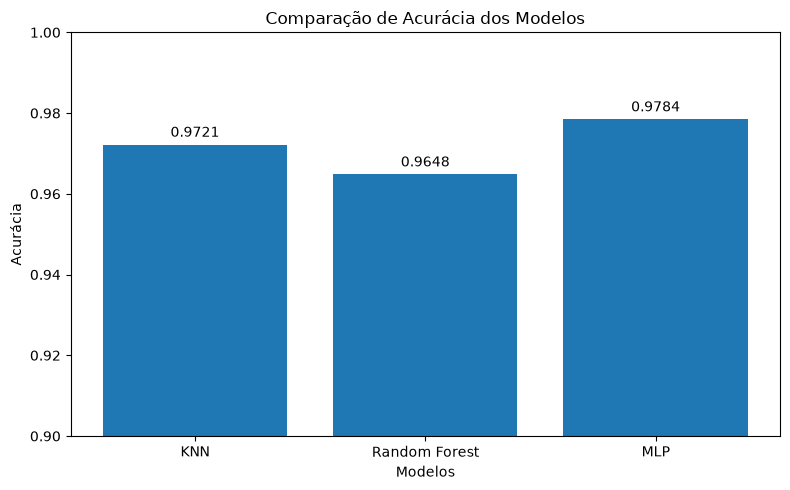

In [58]:
modelos = ["KNN", "Random Forest", "MLP"]

acuracias = [
    0.972143,
    0.964786,
    0.978429
]

plt.figure(figsize=(8, 5))

plt.bar(modelos, acuracias)

plt.title("Comparação de Acurácia dos Modelos")
plt.xlabel("Modelos")
plt.ylabel("Acurácia")

plt.ylim(0.90, 1.00)

for i, valor in enumerate(acuracias):
    plt.text(
        i,
        valor + 0.002,
        f"{valor:.4f}",
        ha="center"
    )

plt.tight_layout()

plt.savefig(
    "graficos/comparacao_modelos.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()



## Análise inicial

O melhor modelo foi a MLP (Rede Neural), com aproximadamente:

97,84% de acurácia no conjunto de teste.

Isso confirma também o que vimos na validação: a MLP teve o melhor desempenho entre os três modelos.

## Matriz de confusão do KNN

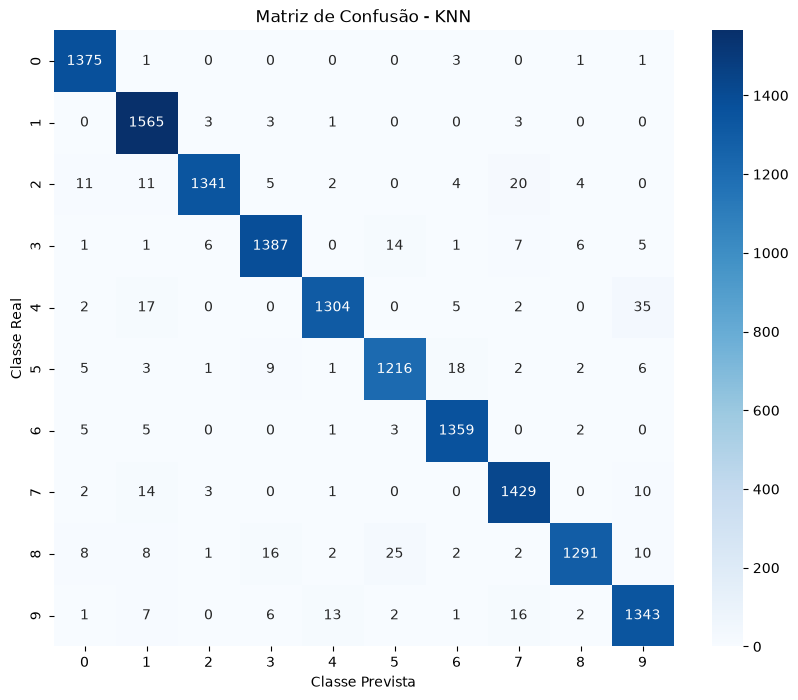

In [29]:
matriz_knn = confusion_matrix(y_test, y_test_pred_knn)

plt.figure(figsize=(10, 8))

sns.heatmap(
    matriz_knn,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Matriz de Confusão - KNN")
plt.xlabel("Classe Prevista")
plt.ylabel("Classe Real")

plt.show()

## Matriz de Confusão da Random Forest

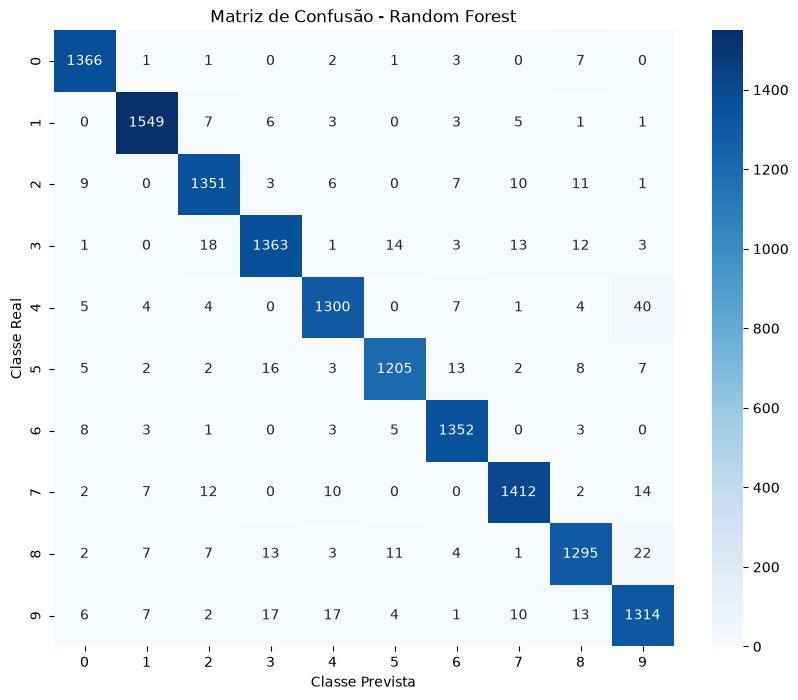

In [30]:
matriz_rf = confusion_matrix(y_test, y_test_pred_rf)

plt.figure(figsize=(10, 8))

sns.heatmap(
    matriz_rf,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Matriz de Confusão - Random Forest")
plt.xlabel("Classe Prevista")
plt.ylabel("Classe Real")

plt.show()

## Terceira Matriz de Confusão da MLP

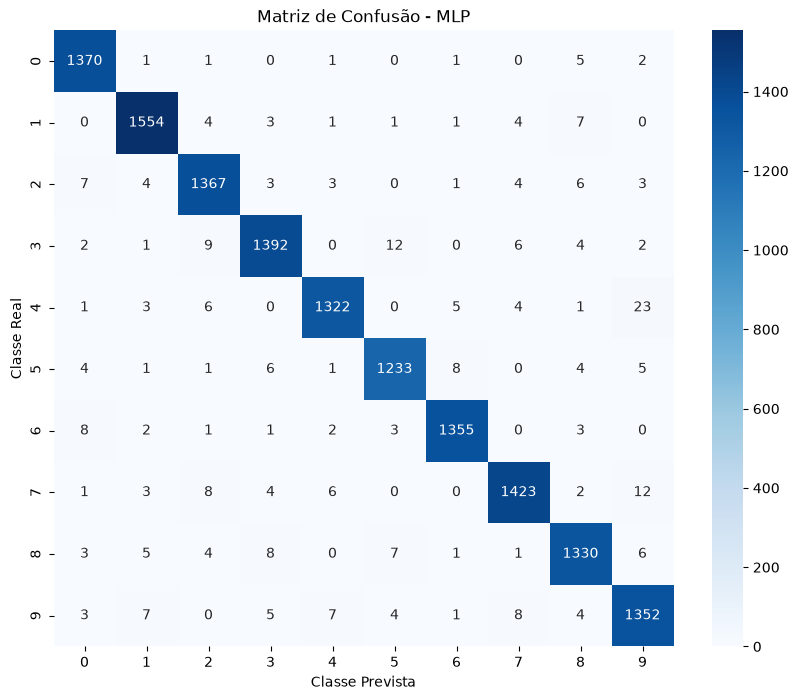

In [74]:
matriz_mlp = confusion_matrix(y_test, y_test_pred_mlp)

plt.figure(figsize=(10, 8))

sns.heatmap(
    matriz_mlp,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Matriz de Confusão - MLP")
plt.xlabel("Classe Prevista")
plt.ylabel("Classe Real")
plt.savefig(
    "graficos/matriz_confusao_mlp.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## Identificar a maior confusão de cada modelo

In [33]:
def maior_confusao(matriz, nome_modelo):
    
    matriz_sem_diagonal = matriz.copy()
    
    np.fill_diagonal(matriz_sem_diagonal, 0)
    
    indice = np.unravel_index(
        np.argmax(matriz_sem_diagonal),
        matriz_sem_diagonal.shape
    )
    
    classe_real = indice[0]
    classe_prevista = indice[1]
    quantidade = matriz_sem_diagonal[indice]
    
    print(f"\n{nome_modelo}")
    print(f"Maior confusão: {classe_real} → {classe_prevista}")
    print(f"Quantidade de erros: {quantidade}")
    

maior_confusao(matriz_knn, "KNN")
maior_confusao(matriz_rf, "Random Forest")
maior_confusao(matriz_mlp, "MLP")


KNN
Maior confusão: 4 → 9
Quantidade de erros: 35

Random Forest
Maior confusão: 4 → 9
Quantidade de erros: 40

MLP
Maior confusão: 4 → 9
Quantidade de erros: 23


## Conclusão técnica da Fase 4

## Conclusão Técnica da Avaliação Comparativa

Os três modelos apresentaram resultados elevados na tarefa de classificação multiclasse dos dígitos manuscritos do dataset MNIST.

A MLP apresentou o melhor desempenho geral no conjunto de teste, obtendo aproximadamente 97,84% de acurácia. O KNN ficou em segundo lugar, com aproximadamente 97,21%, enquanto a Random Forest apresentou aproximadamente 96,48%.

A análise das matrizes de confusão mostrou um padrão semelhante entre os três modelos. A maior confusão ocorreu quando imagens do dígito 4 foram classificadas como dígito 9.

No KNN, essa confusão ocorreu 35 vezes. Na Random Forest, ocorreu 40 vezes. Já na MLP, que apresentou o melhor desempenho geral, essa confusão ocorreu 23 vezes.

Esse resultado indica que determinados estilos de escrita manuscrita podem apresentar características visuais semelhantes entre os dígitos 4 e 9, dificultando a separação dessas classes.

Considerando as métricas globais de Accuracy, Precision, Recall e F1-Score, a MLP foi o modelo com melhor desempenho entre os três modelos avaliados. Além disso, apresentou a menor quantidade de erros na maior confusão identificada.

Em relação ao custo computacional, os modelos possuem características diferentes. O KNN possui treinamento simples, mas a etapa de previsão pode exigir maior custo computacional devido à comparação com os exemplos de treinamento. A Random Forest demanda a construção de múltiplas árvores durante o treinamento. A MLP exige um processo iterativo de treinamento e ajuste dos pesos da rede neural, mas apresentou o melhor resultado de desempenho neste experimento.

Portanto, considerando os resultados obtidos neste projeto, a MLP foi selecionada como o melhor modelo para ser utilizada nos próximos testes de robustez e inferência com imagens manuscritas próprias.

## FASE 5 — Testes de Robustez e Generalização Extrema

## Criar os dados de treinamento sem 4 e 7

In [34]:
classes_ocultadas = [4, 7]

mascara_treino = ~np.isin(y_train, classes_ocultadas)

X_train_masked = X_train_norm[mascara_treino]
y_train_masked = y_train[mascara_treino]

print("Quantidade original de imagens de treino:", len(y_train))
print("Quantidade após ocultar as classes 4 e 7:", len(y_train_masked))

print("\nClasses disponíveis no treinamento:")
print(np.unique(y_train_masked))

Quantidade original de imagens de treino: 49000
Quantidade após ocultar as classes 4 e 7: 39118

Classes disponíveis no treinamento:
[0 1 2 3 5 6 8 9]


## Treinar uma nova MLP sem conhecer 4 e 7

In [35]:
mlp_masked = MLPClassifier(
    hidden_layer_sizes=(150,),
    learning_rate_init=0.001,
    max_iter=30,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1
)

mlp_masked.fit(X_train_masked, y_train_masked)

print("MLP treinada sem conhecer os dígitos 4 e 7!")

MLP treinada sem conhecer os dígitos 4 e 7!


## Criar o conjunto de teste contendo apenas 4 e 7

In [36]:
mascara_teste_ocultadas = np.isin(y_test, classes_ocultadas)

X_test_ocultadas = X_test_norm[mascara_teste_ocultadas]
y_test_ocultadas = y_test[mascara_teste_ocultadas]

print("Quantidade de imagens de teste das classes 4 e 7:", len(y_test_ocultadas))

print("\nDistribuição das classes:")
print(pd.Series(y_test_ocultadas).value_counts().sort_index())

Quantidade de imagens de teste das classes 4 e 7: 2824

Distribuição das classes:
4    1365
7    1459
Name: count, dtype: int64


## Fazer as previsões das classes ocultadas

In [37]:
y_pred_ocultadas = mlp_masked.predict(X_test_ocultadas)

print("Previsões concluídas!")
print("\nClasses previstas pelo modelo:")
print(np.unique(y_pred_ocultadas))

Previsões concluídas!

Classes previstas pelo modelo:
[0 1 2 3 5 6 8 9]


## Analisar as previsões dos dígitos 4 e 7

In [38]:
for digito in classes_ocultadas:
    
    previsoes_digito = y_pred_ocultadas[y_test_ocultadas == digito]
    
    print(f"\nDÍGITO REAL: {digito}")
    print(pd.Series(previsoes_digito).value_counts().sort_values(ascending=False))


DÍGITO REAL: 4
9    1103
2      88
6      83
8      54
1      16
0       9
3       7
5       5
Name: count, dtype: int64

DÍGITO REAL: 7
9    791
3    425
2    166
1     34
0     23
8     16
5      4
Name: count, dtype: int64


## Calcular as porcentagens automaticamente

In [39]:
for digito in classes_ocultadas:
    
    previsoes_digito = y_pred_ocultadas[y_test_ocultadas == digito]
    
    distribuicao_previsoes = (
        pd.Series(previsoes_digito)
        .value_counts(normalize=True)
        .sort_values(ascending=False)
        * 100
    )
    
    print(f"\nDÍGITO REAL: {digito}")
    print(distribuicao_previsoes.round(2))


DÍGITO REAL: 4
9    80.81
2     6.45
6     6.08
8     3.96
1     1.17
0     0.66
3     0.51
5     0.37
Name: proportion, dtype: float64

DÍGITO REAL: 7
9    54.22
3    29.13
2    11.38
1     2.33
0     1.58
8     1.10
5     0.27
Name: proportion, dtype: float64


## Gráfico da distribuição das previsões

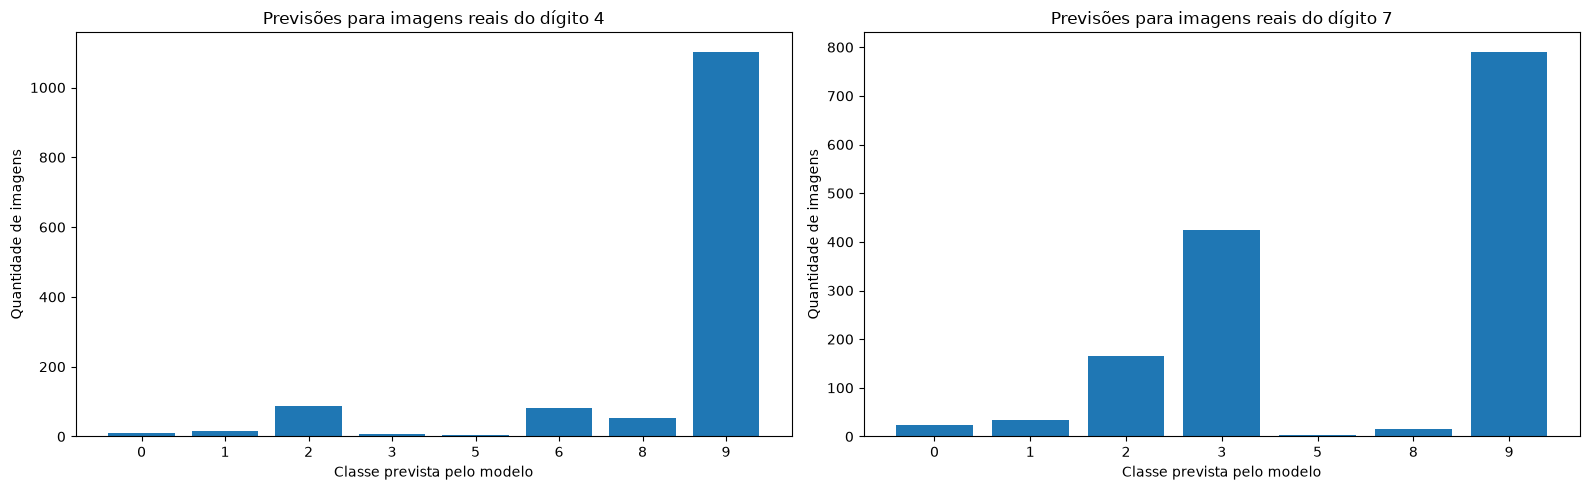

In [75]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, digito in zip(axes, classes_ocultadas):

    previsoes_digito = y_pred_ocultadas[y_test_ocultadas == digito]

    distribuicao = (
        pd.Series(previsoes_digito)
        .value_counts()
        .sort_index()
    )

    ax.bar(
        distribuicao.index.astype(str),
        distribuicao.values
    )

    ax.set_title(
        f"Previsões para imagens reais do dígito {digito}"
    )

    ax.set_xlabel("Classe prevista pelo modelo")
    ax.set_ylabel("Quantidade de imagens")

plt.tight_layout()

plt.savefig(
    "graficos/classes_ocultadas.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Análise da Fase 5 em Markdown

## Fase 5 — Teste de Robustez: Class Masking

Para avaliar a capacidade de generalização do modelo diante de classes nunca observadas, os dígitos 4 e 7 foram completamente removidos do conjunto de treinamento.

A MLP mascarada foi treinada utilizando apenas as classes 0, 1, 2, 3, 5, 6, 8 e 9. Após a remoção dos dígitos 4 e 7, o conjunto de treinamento passou de 49.000 para 39.118 imagens.

Em seguida, o modelo foi testado exclusivamente com 2.824 imagens pertencentes às classes ocultadas, sendo 1.365 imagens do dígito 4 e 1.459 imagens do dígito 7.

Como esperado, o modelo não previu as classes 4 ou 7, pois essas classes nunca foram apresentadas durante o treinamento. As previsões foram realizadas apenas entre as classes conhecidas pelo modelo.

Para as imagens cujo dígito real era 4, a principal previsão foi o dígito 9, representando 80,81% dos casos. As demais previsões ficaram distribuídas principalmente entre os dígitos 2 e 6.

Para as imagens cujo dígito real era 7, o modelo apresentou maior distribuição entre diferentes classes. O dígito 9 foi previsto em 54,22% dos casos, seguido pelo dígito 3 com 29,13% e pelo dígito 2 com 11,38%.

Esse experimento demonstra uma limitação importante dos classificadores tradicionais: quando recebem uma entrada pertencente a uma classe desconhecida, o modelo não reconhece automaticamente que aquela classe é desconhecida. Em vez disso, é obrigado a associar a entrada a uma das classes que conhece.

Portanto, mesmo imagens pertencentes a classes nunca observadas durante o treinamento receberam previsões com classes conhecidas. Esse comportamento é relevante em aplicações reais, pois um modelo pode apresentar uma classificação aparentemente segura mesmo quando recebe dados fora do domínio das classes utilizadas no treinamento.

## Abrir e visualizar a imagem do dígito 3

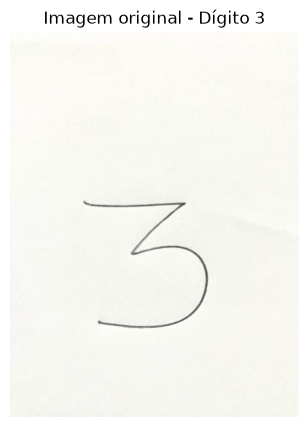

In [43]:
caminho_imagem = os.path.join(
    "imagens_proprias",
    "digito_3.jpeg"
)

imagem_original = Image.open(caminho_imagem)

plt.figure(figsize=(5, 5))
plt.imshow(imagem_original)
plt.title("Imagem original - Dígito 3")
plt.axis("off")

plt.show()

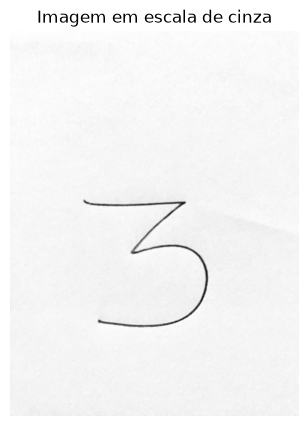

In [44]:
imagem_cinza = imagem_original.convert("L")

plt.figure(figsize=(5, 5))
plt.imshow(imagem_cinza, cmap="gray")
plt.title("Imagem em escala de cinza")
plt.axis("off")

plt.show()

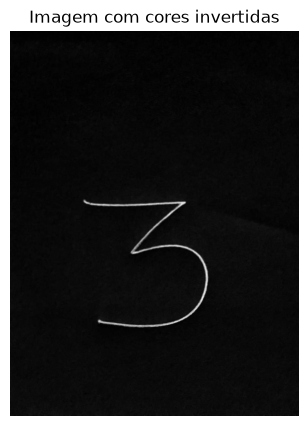

In [45]:
imagem_invertida = ImageOps.invert(imagem_cinza)

plt.figure(figsize=(5, 5))
plt.imshow(imagem_invertida, cmap="gray")
plt.title("Imagem com cores invertidas")
plt.axis("off")

plt.show()

## Criar a Bounding Box do dígito

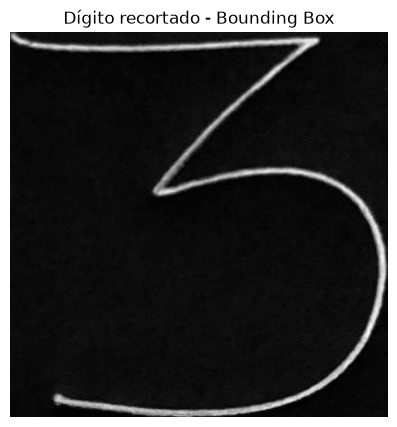

In [46]:
import numpy as np

imagem_array = np.array(imagem_invertida)

# Encontrar os pixels que pertencem ao dígito
pixels_digito = imagem_array > 50

# Encontrar linhas e colunas onde existe o dígito
linhas = np.where(np.any(pixels_digito, axis=1))[0]
colunas = np.where(np.any(pixels_digito, axis=0))[0]

# Criar os limites da bounding box
y_min, y_max = linhas[0], linhas[-1]
x_min, x_max = colunas[0], colunas[-1]

# Recortar somente a região do dígito
imagem_recortada = imagem_invertida.crop(
    (x_min, y_min, x_max + 1, y_max + 1)
)

# Mostrar o resultado
plt.figure(figsize=(5, 5))
plt.imshow(imagem_recortada, cmap="gray")
plt.title("Dígito recortado - Bounding Box")
plt.axis("off")

plt.show()

## Centralizar e redimensionar para 28 × 28

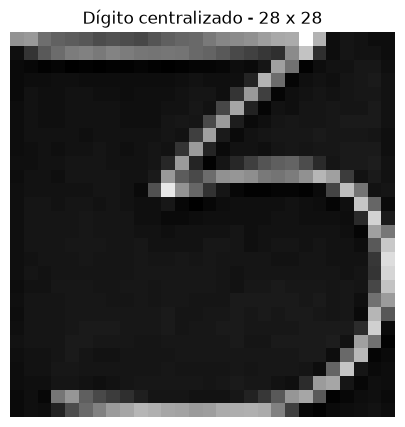

In [47]:
# Tamanho do recorte atual
largura, altura = imagem_recortada.size

# Criar uma imagem quadrada preta
lado = max(largura, altura)

imagem_quadrada = Image.new(
    "L",
    (lado, lado),
    color=0
)

# Calcular posição para centralizar o dígito
x = (lado - largura) // 2
y = (lado - altura) // 2

# Colocar o dígito no centro
imagem_quadrada.paste(
    imagem_recortada,
    (x, y)
)

# Redimensionar para o padrão MNIST
imagem_28x28 = imagem_quadrada.resize((28, 28))

# Mostrar resultado
plt.figure(figsize=(5, 5))
plt.imshow(imagem_28x28, cmap="gray")
plt.title("Dígito centralizado - 28 x 28")
plt.axis("off")

plt.show()

## Normalizar a imagem para o intervalo [0.0, 1.0]

In [48]:
imagem_normalizada = np.array(imagem_28x28, dtype=np.float32) / 255.0

print("Formato da imagem:", imagem_normalizada.shape)
print("Valor mínimo:", imagem_normalizada.min())
print("Valor máximo:", imagem_normalizada.max())

Formato da imagem: (28, 28)
Valor mínimo: 0.003921569
Valor máximo: 0.38431373


## Preparar a imagem para a MLP

In [49]:
X_imagem_propria = imagem_normalizada.reshape(1, -1)

print("Formato para o modelo:", X_imagem_propria.shape)

Formato para o modelo: (1, 784)


## Fazer a previsão

In [50]:
previsao = mlp_final.predict(X_imagem_propria)

print("Dígito previsto pela MLP:", previsao[0])

Dígito previsto pela MLP: 5


In [76]:
probabilidades = mlp_final.predict_proba(X_imagem_propria)[0]

for digito, probabilidade in enumerate(probabilidades):
    print(f"Dígito {digito}: {probabilidade:.4f}")

Dígito 0: 0.0011
Dígito 1: 0.0003
Dígito 2: 0.1184
Dígito 3: 0.0009
Dígito 4: 0.0000
Dígito 5: 0.8061
Dígito 6: 0.0041
Dígito 7: 0.0451
Dígito 8: 0.0111
Dígito 9: 0.0128


## Pipeline melhorado para o dígito 3

In [51]:
from PIL import Image, ImageOps, ImageEnhance
import numpy as np

def preprocessar_digito(caminho):

    # 1. Abrir e converter para escala de cinza
    imagem = Image.open(caminho).convert("L")

    # 2. Inverter as cores
    imagem = ImageOps.invert(imagem)

    # 3. Converter para array
    array = np.array(imagem)

    # 4. Localizar o dígito
    mascara = array > 30

    linhas = np.where(np.any(mascara, axis=1))[0]
    colunas = np.where(np.any(mascara, axis=0))[0]

    y_min, y_max = linhas[0], linhas[-1]
    x_min, x_max = colunas[0], colunas[-1]

    # 5. Recortar o dígito
    imagem_recortada = imagem.crop(
        (x_min, y_min, x_max + 1, y_max + 1)
    )

    # 6. Aumentar o contraste do traço
    imagem_recortada = ImageEnhance.Contrast(
        imagem_recortada
    ).enhance(3)

    # 7. Criar canvas quadrado
    largura, altura = imagem_recortada.size

    lado = max(largura, altura)

    imagem_quadrada = Image.new(
        "L",
        (lado, lado),
        color=0
    )

    x = (lado - largura) // 2
    y = (lado - altura) // 2

    imagem_quadrada.paste(
        imagem_recortada,
        (x, y)
    )

    # 8. Redimensionar para 28 x 28
    imagem_final = imagem_quadrada.resize(
        (28, 28)
    )

    # 9. Normalizar
    array_final = (
        np.array(imagem_final, dtype=np.float32) / 255.0
    )

    # 10. Preparar para o modelo
    X_final = array_final.reshape(1, -1)

    return imagem_final, array_final, X_final

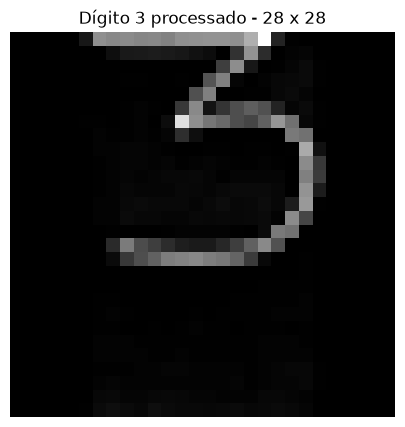

Formato: (28, 28)
Valor mínimo: 0.0
Valor máximo: 0.56078434


In [52]:
caminho_3 = os.path.join(
    "imagens_proprias",
    "digito_3.jpeg"
)

imagem_final_3, array_final_3, X_final_3 = preprocessar_digito(
    caminho_3
)

plt.figure(figsize=(5, 5))
plt.imshow(imagem_final_3, cmap="gray")
plt.title("Dígito 3 processado - 28 x 28")
plt.axis("off")

plt.show()

print("Formato:", array_final_3.shape)
print("Valor mínimo:", array_final_3.min())
print("Valor máximo:", array_final_3.max())

## Melhorar a centralização do dígito

In [53]:
def preprocessar_digito_mnist(caminho):

    # 1. Abrir e converter para escala de cinza
    imagem = Image.open(caminho).convert("L")

    # 2. Inverter as cores
    imagem = ImageOps.invert(imagem)

    # 3. Converter para array
    array = np.array(imagem)

    # 4. Criar máscara apenas para os pixels mais claros
    mascara = array > 100

    # Encontrar linhas e colunas do dígito
    linhas = np.where(np.any(mascara, axis=1))[0]
    colunas = np.where(np.any(mascara, axis=0))[0]

    # Bounding box
    y_min, y_max = linhas[0], linhas[-1]
    x_min, x_max = colunas[0], colunas[-1]

    # 5. Recortar o dígito
    imagem_recortada = imagem.crop(
        (x_min, y_min, x_max + 1, y_max + 1)
    )

    # 6. Aumentar contraste
    imagem_recortada = ImageEnhance.Contrast(
        imagem_recortada
    ).enhance(4)

    # Tamanho atual
    largura, altura = imagem_recortada.size

    # 7. Redimensionar mantendo proporção
    # O MNIST possui margem ao redor do dígito,
    # então usamos no máximo 20 pixels
    escala = 20 / max(largura, altura)

    nova_largura = int(largura * escala)
    nova_altura = int(altura * escala)

    imagem_redimensionada = imagem_recortada.resize(
        (nova_largura, nova_altura)
    )

    # 8. Criar canvas final 28 x 28
    imagem_final = Image.new(
        "L",
        (28, 28),
        color=0
    )

    # Centralizar
    x = (28 - nova_largura) // 2
    y = (28 - nova_altura) // 2

    imagem_final.paste(
        imagem_redimensionada,
        (x, y)
    )

    # 9. Normalizar
    array_final = (
        np.array(imagem_final, dtype=np.float32) / 255.0
    )

    # 10. Preparar para a MLP
    X_final = array_final.reshape(1, -1)

    return imagem_final, array_final, X_final

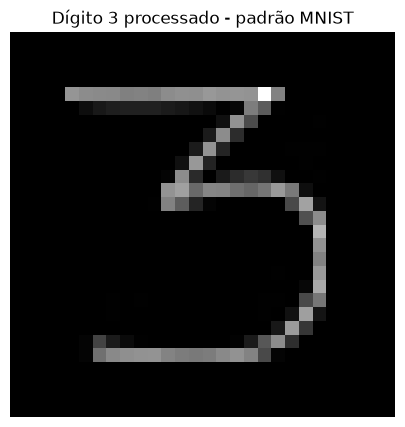

Formato: (28, 28)
Valor mínimo: 0.0
Valor máximo: 0.6862745


In [54]:
imagem_final_3, array_final_3, X_final_3 = (
    preprocessar_digito_mnist(caminho_3)
)

plt.figure(figsize=(5, 5))
plt.imshow(imagem_final_3, cmap="gray")
plt.title("Dígito 3 processado - padrão MNIST")
plt.axis("off")

plt.show()

print("Formato:", array_final_3.shape)
print("Valor mínimo:", array_final_3.min())
print("Valor máximo:", array_final_3.max())

## Fazer a nova previsão do número 3

In [55]:
previsao_final_3 = mlp_final.predict(X_final_3)

probabilidades_final_3 = mlp_final.predict_proba(X_final_3)[0]

print("Dígito previsto pela MLP:", previsao_final_3[0])

print("\nProbabilidades:")
for digito, probabilidade in enumerate(probabilidades_final_3):
    print(f"Dígito {digito}: {probabilidade:.4f}")

Dígito previsto pela MLP: 3

Probabilidades:
Dígito 0: 0.0114
Dígito 1: 0.0181
Dígito 2: 0.1340
Dígito 3: 0.6923
Dígito 4: 0.0000
Dígito 5: 0.1293
Dígito 6: 0.0007
Dígito 7: 0.0002
Dígito 8: 0.0088
Dígito 9: 0.0051


## Após melhorar o pré-processamento, especialmente o recorte e a centralização do dígito, a MLP passou a reconhecer corretamente a imagem manuscrita própria como o dígito 3.

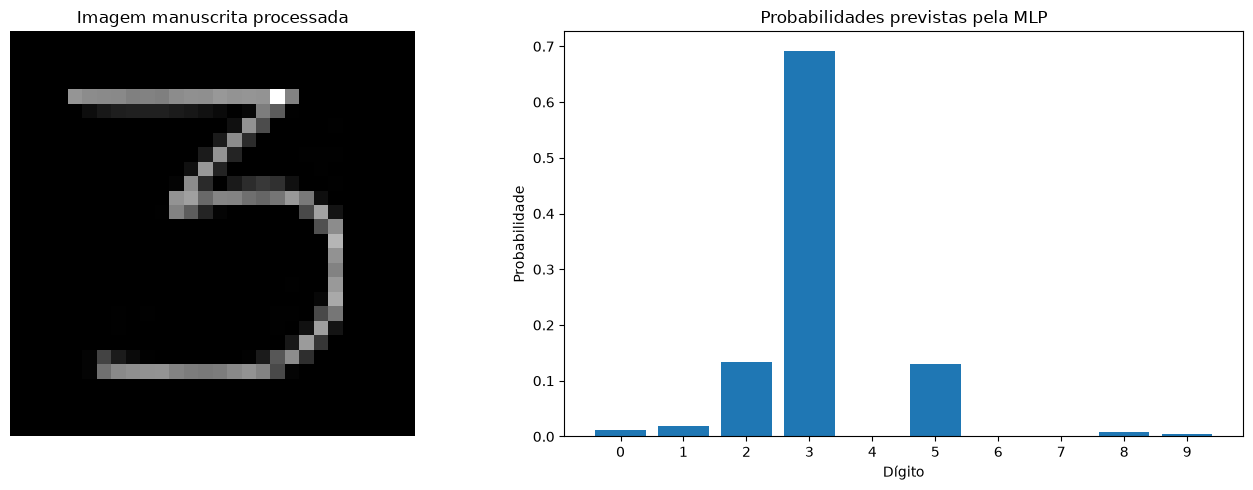

In [76]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Imagem processada
axes[0].imshow(imagem_final_3, cmap="gray")
axes[0].set_title("Imagem manuscrita processada")
axes[0].axis("off")

# Probabilidades
digitos = np.arange(10)

axes[1].bar(
    digitos,
    probabilidades_final_3
)

axes[1].set_title("Probabilidades previstas pela MLP")
axes[1].set_xlabel("Dígito")
axes[1].set_ylabel("Probabilidade")
axes[1].set_xticks(digitos)

plt.tight_layout()

plt.savefig(
    "graficos/imagem_manuscrita_probabilidades.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Conclusão da Fase 5.3

## Fase 5.3 — Desafio C: Inferência com Imagem Manuscrita Própria

Para avaliar a capacidade de generalização do melhor modelo desenvolvido, foi utilizada uma imagem manuscrita própria contendo o dígito 3, escrita manualmente em uma folha branca com traço escuro.

A imagem original foi submetida a um pipeline de pré-processamento para aproximar suas características do padrão utilizado pelo dataset MNIST.

O pipeline desenvolvido realizou as seguintes etapas:

1. Conversão da imagem para escala de cinza;
2. Inversão das cores, transformando o traço escuro em pixels claros sobre fundo escuro;
3. Identificação automática da região contendo o dígito por meio de uma bounding box;
4. Recorte da região relevante da imagem;
5. Redimensionamento mantendo a proporção do dígito;
6. Centralização do dígito em uma imagem de 28 × 28 pixels;
7. Normalização dos valores dos pixels para o intervalo entre 0.0 e 1.0;
8. Transformação da imagem em um vetor contendo 784 características.

A imagem processada foi utilizada como entrada para o melhor modelo desenvolvido durante o projeto, a MLP.

A primeira versão do pré-processamento apresentou uma classificação incorreta, identificando o dígito 3 como 5. Após a melhoria do pipeline, especialmente no processo de identificação da região do dígito, recorte, redimensionamento e centralização, o modelo passou a classificar corretamente a imagem manuscrita.

O resultado final classificou o dígito manuscrito como 3, com probabilidade de 69,23%.

As maiores probabilidades atribuídas pelo modelo foram:

- Dígito 3: 69,23%;
- Dígito 2: 13,40%;
- Dígito 5: 12,93%.

Esse experimento demonstra a importância do pré-processamento em aplicações de Machine Learning. Mesmo utilizando um modelo com alta acurácia no dataset MNIST, imagens provenientes do mundo real podem apresentar diferenças significativas de iluminação, espessura do traço, centralização e formato do dígito.

Portanto, a melhoria do pipeline de pré-processamento foi fundamental para aproximar a imagem manuscrita própria do padrão utilizado durante o treinamento e permitir a classificação correta pelo modelo.